# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [33]:
import random
class Card: #single playing card
    #Card will have a suit,a rank,and a blackjack value
    def __init__(self,suit,rank): #When a card object will be made, it will store its rank and suit
        self.rank=rank
        self.suit=suit
        self.value=self.get_value() #for blackjack values of the card
    def get_value(self): #this function is to determine the blackjack value of the card
        #as we know J,Q,K holds 10 points and ace can be 1 or 11
        #number cards is their numeric value
        if self.rank=="A":
            return 11   #ace is 11 or 1 so i will implement 1 logic later
        elif self.rank in ['Q','K','J']:
            return 10
        else:
            return int(self.rank)  #number cards
    def __str__(self):      #string representation of the card
        return f"{self.rank}of{self.suit}"
        


In [34]:
class Deck:
    suits=["Hearts","Clubs","Diamonds","Spades"]
    ranks=["A","2","3","4","5","6","7","8",'9',"10","J","K","Q"]
    def __init__(self,numofdecks=6):
        self.numofdecks=numofdecks  #this is number of 52 card decks
        self.cards=[] #this list will hold all card objects
        self.plastic_card_position=None #for now it is none
        self.create_deck()  #this function creates the deck
    def create_deck(self): 
        self.cards=[]  #clearing existing cards 
        for _ in range(self.numofdecks):   #looping over 6 number of decks
            for suit in Deck.suits:   #looping over suits of decks
                for rank in Deck.ranks:   #looping over ranks of decks
                    self.cards.append(Card(suit,rank))  #appending Card object with suit and rank in a list
        self.shuffle()  #shuffle deck after creation
        total_cards=len(self.cards)
        #placing plastic card randomly between 15%-25% of total cards
        self.plastic_card_position=random.randint(int(total_cards*0.15),int(total_cards*0.25))
    def shuffle(self):
        random.shuffle(self.cards)  #shuffling the deck randomly
    def draw_card(self):
        #this function task is to draw the top card from deck
        #and returns the card object and true or false if the plastc card reached or not
        if not self.cards:      #if no cards are left then i am creating new deck
            self.create_deck()
        card=self.cards.pop(0)  #drawing the top card
        #now i am checking if the number of cards remaining has reached the plastic card position
        #if the remaining cards are less than or equal to this positionit means the plastic card has reached 
        #and the deck should be reshuffled before the next round:
        needs_reshuffle=len(self.cards)==self.plastic_card_position
        return card,needs_reshuffle
        
        

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [35]:
class Hand:     
    def __init__(self):
        self.cards=[]  #list for storing cards
    def add_card(self,card): #this function will add the card to the hand
        pass   
    def get_value(self):  #this will give the total value of the hand
        pass
    def is_blackjack(self): #will check if the hand is a blackjack or not
        pass #blackjack is exactly 21 with two cards
    def is_bust(self): #if the handvalue exceeds 21 then it will be true
        pass
class Player:
    def __init__(self,name,chips=1000):
        self.name=name #this is the name of the player
        self.chips=chips  #this is number of chips the player has
        self.hand=Hand() #this is player current hand
    def hit(self,deck): #will draw a card from the deck and will add it to the player hand
        pass
    def show_hand(self):  #for showing current value of the hand
        pass
    def get_value(self):  #for the value of card
        pass
class Dealer(Player):  #inheriting from player
    def __init__(self):
        super().__init__("Dealer")   #creating a player Dealer
    def play(self,deck): #this function will control dealer's action
        pass
class Game:
    def __init__(self,num_players=3):
        self.players=[] #list of players
        self.dealer=Dealer() #this is dealer object
        self.deck=Deck() #this is the deck used in the game
    def start_round(self):#will start a new round of blackjack
        pass
    def play_round(self): #will manage the actions of players and dealer
        pass
    def resolve_round(self):#will determine the winners and update player chips
        pass
    def simulate_games(self,n):  #will run multiple blackjack games
        pass
class StrategyPlayer(Player): #player will use a strategy
    def __init__(self,name,chips=1000,threshold=0): #initializing strategy player with card counting threshold
        super().__init__(name,chips)
        self.count=0   #count of seen cards
        self.threshold=threshold #will decide hit or stand
    def update_count(self,card): #will updatw running card count when a card is seen
        pass
    def decide(self):  #deciding to hit or stand based on strategy
        pass
    def play_turn(self,deck): #player turn using strategy
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [36]:
class Hand:
    def __init__(self):
        self.cards=[]  #for storing card objects
    def add_card(self,card):
        self.cards.append(card) #here i am adding card to the list
    def get_value(self): #for calculating total blackjack value of the hand
        total=0  # this is total value of hand
        aces=0
        for card in self.cards:  #looping through each card
            total=total+card.value #adding the card value to the total
            if card.rank=='A':
                aces=aces+1 #counting how many aces are in the hand
        while total>21 and aces>0: #adjusting aces from 11 to 1 if total exceeds 21
            total=total-10 #converting one ace from 11 to 1
            aces=aces-1  #reducing ace count
        return total
    def is_blackjack(self): # will return true if i have two cards and their value equals 21 which means it is a blackjack
        return len(self.cards)==2 and self.get_value()==21
    def is_bust(self):# will return true if values exceed 21 which ultimately means player lose
        return self.get_value()>21
    
 

In [37]:
class Player: #human player
    def __init__(self,name="Human",chips=100):
        self.name=name
        self.chips=chips
        self.hand=Hand() #player current hand that is instance of hand class
    def hit(self,deck):
        card,reshuffle=deck.draw_card() #drawing a card from deck
        self.hand.add_card(card)    #adding it to hand
    def show_hand(self):  #displaying player cards and total value
        print(f"{self.name}'s hand: ", ", ".join(str(card) for card in self.hand.cards))
        print("Total value:",self.hand.get_value())
    def get_value(self): #will return the total value of the players hand
        return self.hand.get_value()
        
    

In [38]:
class Dealer(Player): #inherits player
    def __init__(self):
        super().__init__(name="Dealer")   #creating a player Dealer
    def play(self,deck):
        while self.hand.get_value()<=16: #dealer is hitting on 16 or lower
            print("Dealer hits")
            self.hit(deck)
        print('Dealer stands')  #if 16 above
        print(f"{self.name}'s hand: ", ", ".join(str(card) for card in self.hand.cards))
        print("Total value:",self.hand.get_value())  #for tota value

In [43]:
class Game:
    def __init__(self, num_players=3):  #3 players will play against dealer
        self.deck=Deck()   #creating deck object
        self.dealer=Dealer() #dealer object
        self.players=[Player(f"Computer_{i+1}") for i in range(num_players)] #list of player objects
        self.needs_reshuffle=False #for whether the plastic card has been reached
        self.strat_player=StrategyPlayer("Counter_Bot",chips=100)
        self.comp_players=[Player(f"Computer_{i+1}",chips=100) for i in range(num_players-1)]
        self.players=[self.strat_player]+self.comp_players #merging them here
    def start_round(self):
        if self.needs_reshuffle: #checking if the deck needs to be reshuffled
            self.deck.create_deck()         #recreating
            self.strat_player.count=0  #resetting the count for the new deck
            self.needs_reshuffle=False      #resetting the reshuffle
        
        self.dealer.hand=Hand()    #creating a new hand for dealer
        for p in self.players:  #giving players hand
            p.hand=Hand()
    #dealing 2 cards to players:
        for _ in range(2):
            for p in self.players:
                self.deal_and_track(p) 
            self.deal_and_track(self.dealer)  #replacing manual dealer for the drawing
    
    def play_round(self):   #for current round
        for p in self.players:
            if isinstance(p, StrategyPlayer):
                p.play_turn(self.deck,self) #letting the bot use its counts
            else:
                while p.get_value()<=16 and not p.hand.is_bust():
                    print(f"{p.name} hits")
                    self.deal_and_track(p)  #drawing the card from deck after hitting
                    p.show_hand()   #here i am showing again the player current hand and total hand value
                if not p.hand.is_bust():  #checking if the player did not bust
                    print(f"{p.name} stands") 
        
        print("\n Dealer's turn:")
        while self.dealer.get_value()<=16:
            print("Dealer hits")
            self.deal_and_track(self.dealer) 
        
        print(f"Dealer stands at {self.dealer.get_value()}")
        self.resolve_round()  #after playing determining the winners and updating the chips

    def resolve_round(self):  #for determining winners losers and chips
       d_val=self.dealer.get_value()  #getting total value of dealer hand
       for p in self.players:
            p_val=p.get_value()   #getting total value of player hand
            if p.hand.is_bust():   #if the player busts
                p.chips-=10    #deducting 10 chips from player total
                print(f"{p.name} busts and loses!")
            elif self.dealer.hand.is_bust() or p_val>d_val:  #if dealer busts or player hand value is greater than dealer hand 
                p.chips+=10 #player wins
                print(f"{p.name} wins!")
            elif p_val<d_val:   #if player hand value is less than dealer hand
                p.chips-=10   #deducting 10 chips from player
                print(f"{p.name} loses!")  #and playe loses
            else:
                print(f"{p.name} pushes (tie).")
    def deal_and_track(self,participant,visible=True):
        card, reshuffle=self.deck.draw_card()   #drawing the card
        participant.hand.add_card(card)  #giving it to the person dealer or player
        if visible:
            self.strat_player.update_count(card)  #if visible then updating count for shown cards
        if reshuffle:  #if needs reshuffling
            self.needs_reshuffle=True
        return card
    def simulate_games(self,n):  #will run multiple rounds
        for i in range(n):  #looping through n rounds 
            print(f"\n ------Round {i+1}-----")
            self.start_round()    #starting a new round
            self.play_round()     #playing the round
        
        print("\n FINAL CHIP COUNTS")
        for p in self.players:   #looping through each player
            print(f"{p.name}:{p.chips} chips")   #here i am printing their names and chips
        for p in self.players:
            total_profit=p.chips-100
            rate=total_profit/n  #n is the number of rounds
            print(f"{p.name} Winnings Rate: {rate:.2f} chips/hand")  #2 decimal places

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [44]:
game=Game(num_players=3)  #initializing deck,player, and dealer
#I am playing 3 rounds to demonstrate functionality
game.simulate_games(3)


 ------Round 1-----
Computer_1 stands
Computer_2 hits
Computer_2's hand:  AofHearts, 3ofDiamonds, 9ofHearts
Total value: 13
Computer_2 hits
Computer_2's hand:  AofHearts, 3ofDiamonds, 9ofHearts, 10ofHearts
Total value: 23

 Dealer's turn:
Dealer stands at 21
Counter_Bot busts and loses!
Computer_1 loses!
Computer_2 busts and loses!

 ------Round 2-----
Computer_1 stands
Computer_2 hits
Computer_2's hand:  2ofDiamonds, 10ofDiamonds, 2ofSpades
Total value: 14
Computer_2 hits
Computer_2's hand:  2ofDiamonds, 10ofDiamonds, 2ofSpades, 7ofSpades
Total value: 21
Computer_2 stands

 Dealer's turn:
Dealer hits
Dealer stands at 20
Counter_Bot busts and loses!
Computer_1 loses!
Computer_2 wins!

 ------Round 3-----
Computer_1 hits
Computer_1's hand:  9ofHearts, 3ofHearts, 5ofClubs
Total value: 17
Computer_1 stands
Computer_2 hits
Computer_2's hand:  9ofDiamonds, 6ofSpades, 7ofClubs
Total value: 22

 Dealer's turn:
Dealer hits
Dealer stands at 21
Counter_Bot busts and loses!
Computer_1 loses!
Com

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [45]:
class StrategyPlayer(Player):
    def __init__(self,name="Counter_Bot",chips=100,threshold=0):   
        super().__init__(name,chips)  #calling the parent class
        self.count=0    #for card counting
        self.threshold=threshold #threshold will decide hit or stay
        
    def update_count(self,card):  #updating the running card count based on cards seen
        rank_str=str(card.rank)  #converting card rank to string
        if rank_str in ['2','3','4','5','6']: #low cards are good for players so increasing the count
            self.count+=1
        elif rank_str in ['10','J','Q','K','A']:#high cards are good for dealer then decreasing the count
            self.count-=1
            
    def decide(self):  #deciding whether to hit or stand
        val = self.get_value()
        if val >= 21:
            return "stand"
    # Essential safety: Never stand on a total where you cannot bust
        if val < 12:
            return "hit"
    
    # Card counting logic:
    # If count is high (positive), more high cards are left in deck. 
    # This favors the dealer (who must hit), so we stand and hope they bust.
        if self.count <= self.threshold:
            return "hit"
        else:
            return "stand"
        
    def play_turn(self,deck,game_instance):  #playing a turn
        while not self.hand.is_bust():  #continue taking actions until the hand busts
            if self.decide()=="hit":
                game_instance.deal_and_track(self) #means deal a card to this player and update the game state 
            else:
                break #stop taking more crads

In [46]:
game=Game(num_players=1) 
print("Sum of seen cards",game.strat_player.count) 
game.strat_player.play_turn(game.deck, game)
print('Final hand:', game.strat_player.get_value())

Sum of seen cards 0
Final hand: 13


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [47]:
class Game:
    def __init__(self,num_computer_players=3,strat_threshold=0,verbose=False):
        self.deck=Deck() #initializing a deck of cards
        self.dealer=Dealer()  #creating the dealer
        self.verbose=verbose    #verbose method
            #creating the strategy player with a threshold for card counting:
        self.strat_player=StrategyPlayer("Strategy_Bot",chips=1000,threshold=strat_threshold)
         #creating N computer players who follow dealer strategy:
        self.comp_players=[Player(f"Comp_{i+1}",chips=1000) for i in range(num_computer_players)]
        self.players=[self.strat_player]+self.comp_players  #combining all players into one list
        self.needs_reshuffle=False  #if deck needs reshuffling

    def log(self,message):
        if self.verbose==True: #print message only if verbode is truee
            print(message)

    def deal_and_track(self,participant):  #dealing one card to a participant and thenn updating strategy player
        card,reshuffle=self.deck.draw_card()  #drawing card from deck
        participant.hand.add_card(card)  #here i am adding to the hand
        self.strat_player.update_count(card)  #strategy player updating count for all seen cards
        if reshuffle:  #if reshuffling is needed then setting it to true
            self.needs_reshuffle=True
        return card 

    def start_round(self): #new round
        if self.needs_reshuffle:
            self.deck.create_deck()  #recreating the deck
            self.strat_player.count=0 #reset card count after shuffle
            self.needs_reshuffle=False
            
        self.dealer.hand=Hand() #resetting hands for dealer and all players
        for p in self.players:
            p.hand=Hand()
            
        for _ in range(2):  #dealing 2 cards to everyone
            for p in self.players:
                self.deal_and_track(p) #deal to player
            self.deal_and_track(self.dealer)  #deal to dealer

    def play_round(self):   
        for p in self.players:
            if isinstance(p, StrategyPlayer):
                # Pass 'self' as the second argument (the game instance)
                p.play_turn(self.deck, self) 
            else:
                # Standard dealer-style logic for computer players
                while p.get_value() <= 16 and not p.hand.is_bust():
                    self.log(f"{p.name} hits")
                    self.deal_and_track(p)
                if not p.hand.is_bust():
                    self.log(f"{p.name} stands") 
        
        self.log("\n Dealer's turn:")
        while self.dealer.get_value() <= 16:
            self.log("Dealer hits")
            self.deal_and_track(self.dealer)
        
        self.log(f"Dealer stands at {self.dealer.get_value()}")
        self.resolve_round()
    def resolve_round(self):  #determining winners and updating chips
        d_val=self.dealer.get_value()   #getting total value of the dealer hand
        d_bust=self.dealer.hand.is_bust()  #checking if dealer has busted 
        
        for p in self.players:  #going through each player
            p_val=p.get_value()
            if p.hand.is_bust():  #if the player busts
                p.chips-=10  #here i am subtracting 10 chips from player
            elif d_bust or p_val>d_val:  #player wins if dealer busts or player hand value is greater than dealer value  
                p.chips+=10 #addingg 10 chips to the player
            elif p_val<d_val:  #player looses if their hand value is less than dealer hand value
                p.chips-=10  #subtracting 10 chips from player
        

In [48]:
test_game=Game(num_computer_players=3,strat_threshold=0,verbose=False)  #3 dealer strategy player
initial_chips=test_game.strat_player.chips   #saving initial chips for strategy player
for r in range(1, 51):  #50 rounds
    if test_game.strat_player.chips<=0:  #stop if strategy is out of money
        print(f"Strategy Player went bust at round {r}!")
        break
    test_game.start_round()  #starting round
    test_game.play_round() #playing the round
    
final_chips=test_game.strat_player.chips   #final winnings
winnings=final_chips-initial_chips

print("Results after 50 rounds")
print(f"Starting Chips: {initial_chips}")
print(f"Final Chips:    {final_chips}")
print(f"Total Winnings: {winnings}")

Results after 50 rounds
Starting Chips: 1000
Final Chips:    680
Total Winnings: -320


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [49]:
import numpy as np
import matplotlib.pyplot as plt
results=[]   #list to store final winnings for each game

for i in range(100):  #creating a new game with 3 dealer strategy player
    game=Game(num_computer_players=3, strat_threshold=0)
    for r in range(50):  #playing 50 rounds
        if game.strat_player.chips>0:
            game.start_round()
            game.play_round()
        else:
            break #stopping early if strategy player is out of money
    winnings=game.strat_player.chips-1000  #calculating net profit/loss that is final chips-starting chips
    results.append(winnings)
#converting results to a numpy array to do the math easily:
results=np.array(results)

In [50]:
total_won=np.sum(results)  #average winnings per round
total_rounds=100*50
avg_per_round=total_won/total_rounds
std_dev=np.std(results)  #standard deviation of winnings of 100 games

wins=np.sum(results>0) #probability of winning and losing
losses=np.sum(results<0)
prob_win=wins/100
prob_loss=losses/100

print(f"Avg Winnings per Round: {avg_per_round}")  #printing statistics
print(f"Standard Deviation: {std_dev}")
print(f"Prob of Winning: {prob_win*100}%")
print(f"Prob of Losing: {prob_loss*100}%")

Avg Winnings per Round: -4.008
Standard Deviation: 71.09036502930618
Prob of Winning: 0.0%
Prob of Losing: 100.0%


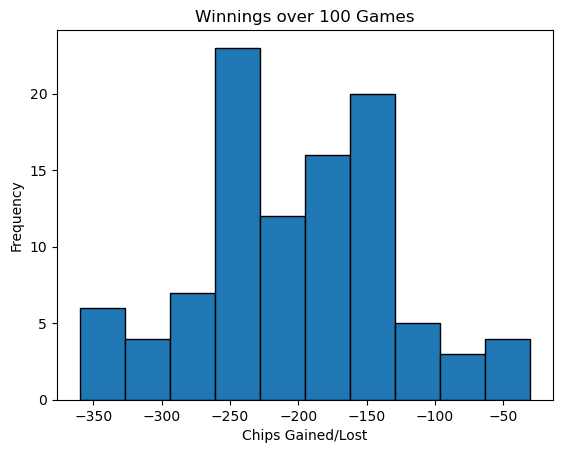

In [51]:
plt.hist(results,bins=10,edgecolor='black')  #using matplotlib to make a histogram
plt.title("Winnings over 100 Games")
plt.xlabel("Chips Gained/Lost")
plt.ylabel("Frequency")
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [52]:
import numpy as np
import matplotlib.pyplot as plt
thresholds=[-5,-2,0,2,5]  #values to test
final_results={}  #to store average net profit for each threshold
print("Scanning thresholds ")
for t in thresholds:  #looping over each threshold
    game_winnings=[]  #to store new net profit/loss
    for i in range(100):  #for 100 simulations
        game=Game(num_computer_players=3,strat_threshold=t) #creating game with threshold t
        for r in range(50):
            if game.strat_player.chips>0:  #stop early if the strategy player runs out of chips
                game.start_round()  #deals initial cards
                game.play_round()
            else:
                break
        net_profit=game.strat_player.chips-1000  #calculating net profit/loss
        game_winnings.append(net_profit)  #adding the net profit/loss for this game to the list
    
    #storing average for this threshold
    final_results[t]=np.mean(game_winnings)   #storing it in final results
    print(f"Threshold {t}: Avg profit per game = {final_results[t]:}") #printing average winnings
optimal_threshold=max(final_results,key=final_results.get)  #optimal value
print(f"\n CONCLUSION ")
print(f"The optimal threshold is: {optimal_threshold}")

Scanning thresholds 
Threshold -5: Avg profit per game = -118.3
Threshold -2: Avg profit per game = -153.0
Threshold 0: Avg profit per game = -188.1
Threshold 2: Avg profit per game = -218.8
Threshold 5: Avg profit per game = -262.3

 CONCLUSION 
The optimal threshold is: -5


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [53]:
class SmartStrategyPlayer(StrategyPlayer):
    def decide(self):
        val=self.hand.get_value()  #getting current total value of the hand
        if val>=17: #if the hand is 17 or higher the player always stands
            return "stand"
        if 12<=val<=16: #player uses card counting stratehy
            #if count is high which is positive then big cards are coming so it will be better to stay and let the dealer busts
            if self.count>self.threshold:
                return "stand"
            else:
                return "hit"
        return "hit"  #player always hitsf for below <=11

smart_results=[]

for i in range(100):  #looping over 100 games
    game=Game(num_computer_players=3,strat_threshold=0) #creating the game
    
    smart_bot=SmartStrategyPlayer("Smart_Bot",chips=1000,threshold=0) #replacing the strategy player with smartstrategyplayer
    game.strat_player=smart_bot
    game.players[0]=smart_bot  #updating the game player list
    
    for r in range(50):  #playing 50 rounds and stopping if the strategy player runs out of chips
        if game.strat_player.chips>0:
            game.start_round()
            game.play_round()
        else:
            break
    
    smart_results.append(game.strat_player.chips-1000)  #calculating net profit/loss

smart_results=np.array(smart_results) #converting the list to a nnumpy array
new_avg=np.sum(smart_results)/(100*50) #new average
new_win_prob=np.mean(smart_results>0)  #new winning probability

print(f"New Smart Strategy Avg Winnings: {new_avg}")
print(f"New Prob of Winning: {new_win_prob*100}%")


New Smart Strategy Avg Winnings: -0.618
New Prob of Winning: 27.0%
